# Analise Exploratoria - Ibovespa historico (fechamento -> retorno)

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display


plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

## 1. Carregamento dos dados
Incluindo Forward Fill

Qtd de NaN antes:  7152


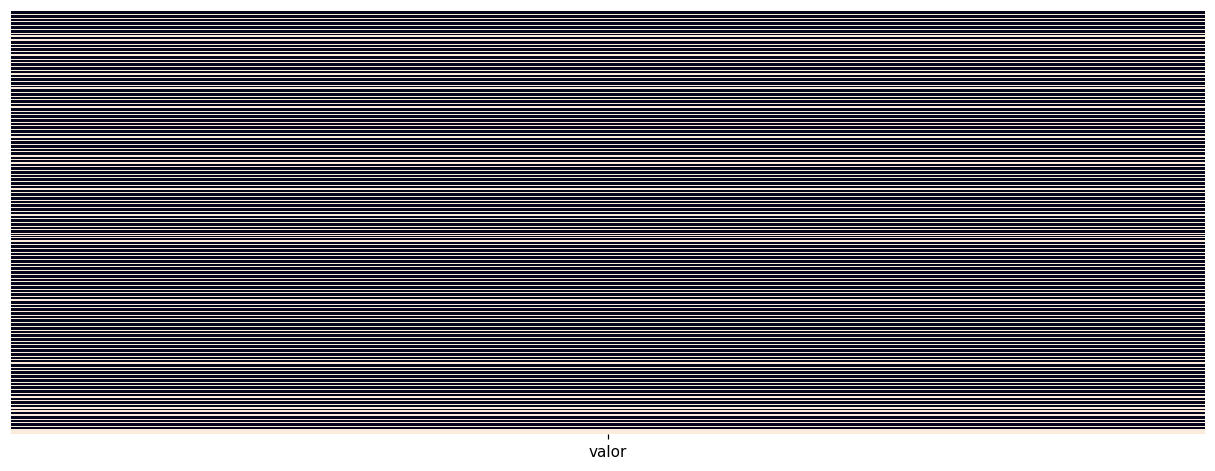

Qtd de NaN depois:  0
1968-01-02 -> 2026-05-22
--- ibov (sem filtro de data) ---


,data,valor
0,1968-01-02,1.000000e-10
1,1968-01-03,1.000000e-10
2,1968-01-04,9.900000e-11
3,1968-01-05,9.700000e-11
4,1968-01-08,9.700000e-11


,data,valor
14393,2026-05-18,176975.82
14394,2026-05-19,174278.86
14395,2026-05-20,177355.73
14396,2026-05-21,177649.86
14397,2026-05-22,176209.61


--- ibov filtrado (>= 2010-01-03) ---


,data,valor
0,2010-01-04,70045.08
1,2010-01-05,70239.82
2,2010-01-06,70729.34
3,2010-01-07,70451.12
4,2010-01-08,70262.70


...

,data,valor
0,1968-01-02,1.000000e-10
1,1968-01-03,1.000000e-10
2,1968-01-04,9.900000e-11
3,1968-01-05,9.700000e-11
4,1968-01-06,9.700000e-11


,data,valor
21321,2026-05-18,176975.82
21322,2026-05-19,174278.86
21323,2026-05-20,177355.73
21324,2026-05-21,177649.86
21325,2026-05-22,176209.61


--- ibov_ff filtrado (>= 2010-01-03) ---


,data,valor
0,2010-01-03,68588.41
1,2010-01-04,70045.08
2,2010-01-05,70239.82
3,2010-01-06,70729.34
4,2010-01-07,70451.12


,data,valor
5979,2026-05-18,176975.82
5980,2026-05-19,174278.86
5981,2026-05-20,177355.73
5982,2026-05-21,177649.86
5983,2026-05-22,176209.61


In [157]:
ibov = pd.read_csv('dados/Historico_IBovespa.csv', encoding='latin-1')
ibov['data'] = pd.to_datetime(ibov['data'], errors='coerce')
ibov['valor'] = pd.to_numeric(ibov['valor'], errors='coerce')
ibov = ibov.sort_values('data').reset_index(drop=True)

print('Qtd de NaN antes: ', ibov['valor'].isna().sum())
sns.heatmap(ibov[['valor']].isnull(), yticklabels=False, cbar=False)
plt.show()

ibov.dropna(inplace=True)
ibov.reset_index(drop=True, inplace=True)

print('Qtd de NaN depois: ', ibov['valor'].isna().sum())
print(ibov['data'].min().date(), '->', ibov['data'].max().date())

print('--- ibov (sem filtro de data) ---')
display(ibov.head())
display(ibov.tail())

ibov_2010 = ibov[ibov['data'] >= '2010-01-03'].reset_index(drop=True)
print('--- ibov filtrado (>= 2010-01-03) ---')
display(ibov_2010.head())
display(ibov_2010.tail())

# versao com forward fill
ibov_ff = pd.read_csv('dados/Historico_IBovespa.csv', encoding='latin-1')
ibov_ff['data'] = pd.to_datetime(ibov_ff['data'], errors='coerce')
ibov_ff['valor'] = pd.to_numeric(ibov_ff['valor'], errors='coerce')
ibov_ff = ibov_ff.sort_values('data').reset_index(drop=True)
ibov_ff['valor'] = ibov_ff['valor'].ffill()
ibov_ff = ibov_ff.dropna().reset_index(drop=True)
ibov_ff = ibov_ff[ibov_ff['data'] <= '2026-05-22'].reset_index(drop=True)

print('--- ibov_ff (com forward fill, sem filtro de data) ---')
display(ibov_ff.head())
display(ibov_ff.tail())

ibov_ff_2010 = ibov_ff[ibov_ff['data'] >= '2010-01-03'].reset_index(drop=True)
print('--- ibov_ff filtrado (>= 2010-01-03) ---')
display(ibov_ff_2010.head())
display(ibov_ff_2010.tail())

## 2. Estatisticas descritivas

In [158]:
print('Describe — sem forward fill (a partir de 2010-01-05):')
display(ibov['valor'][ibov['data'] >= '2010-01-05'].describe())

print('Describe — com forward fill (a partir de 2010-01-05):')
display(ibov_ff['valor'][ibov_ff['data'] >= '2010-01-05'].describe())

Describe — sem forward fill (a partir de 2010-01-05):


count      4062.000000
mean      87002.956123
std       33197.172314
min       37497.470000
25%       57747.647500
50%       76552.725000
75%      113582.280000
max      198657.330000
Name: valor, dtype: float64

Describe — com forward fill (a partir de 2010-01-05):


count      5982.000000
mean      86944.945856
std       33190.575649
min       37497.470000
25%       57796.795000
50%       76410.060000
75%      113619.847500
max      198657.330000
Name: valor, dtype: float64

## 3. Serie temporal

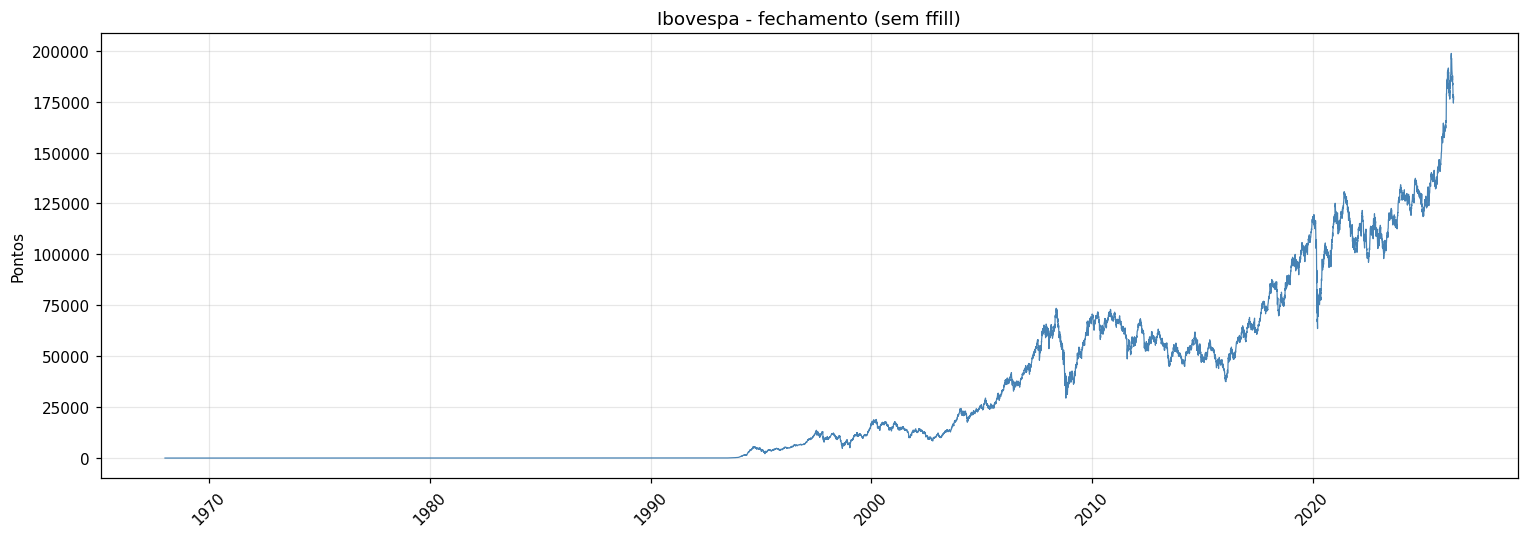

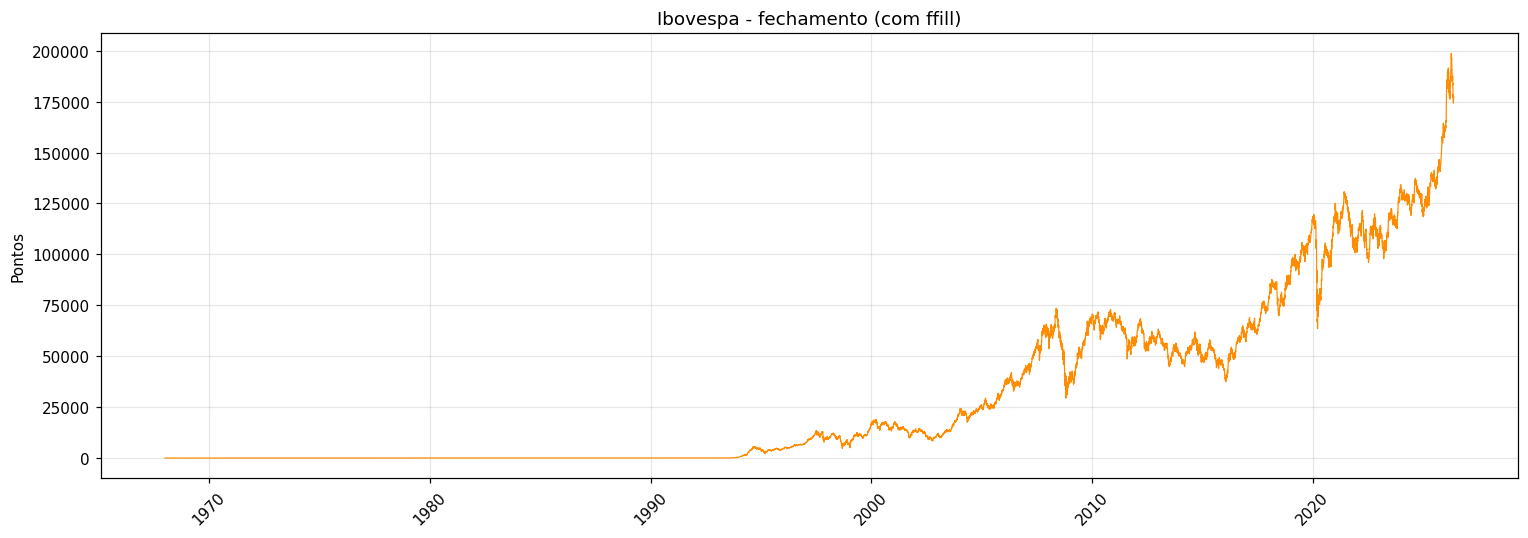

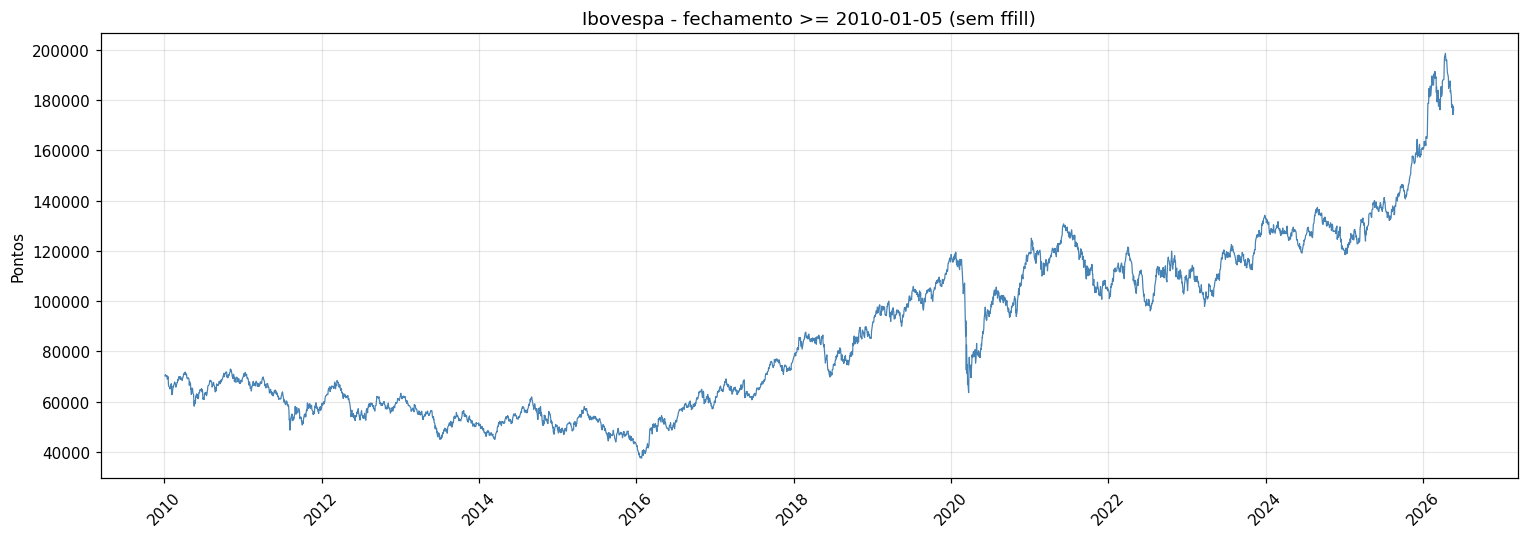

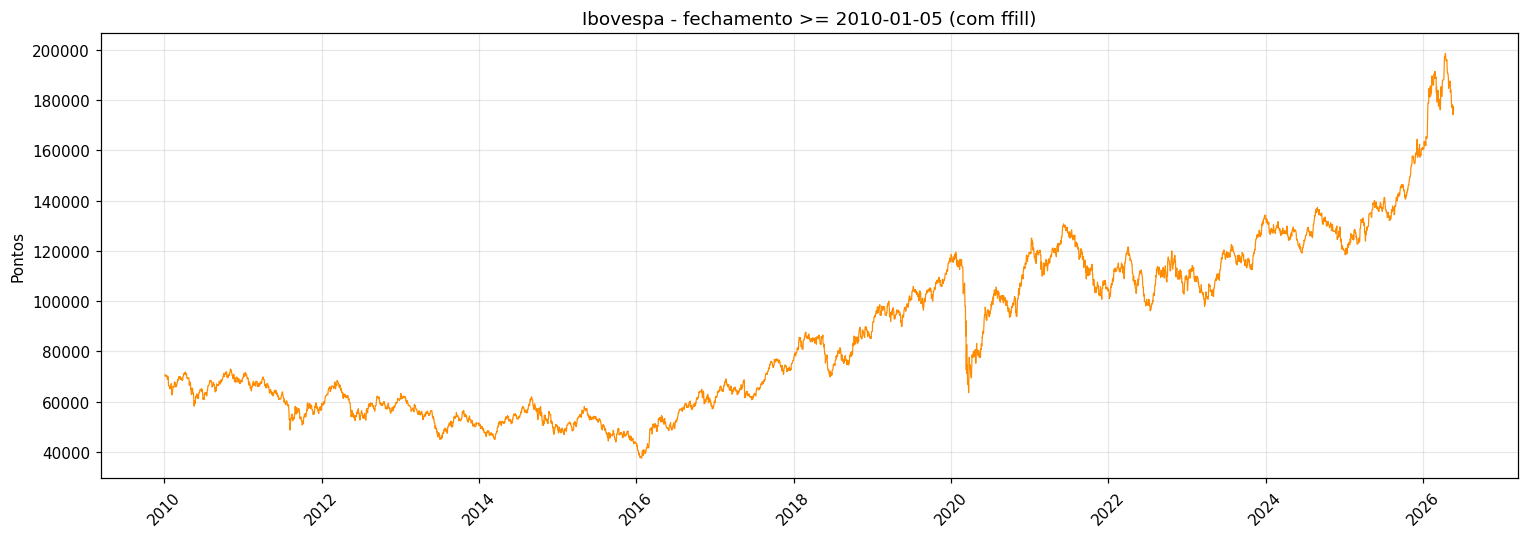

In [159]:
# --- sem ffill: serie completa ---
plt.figure(figsize=(14, 5))
plt.plot(ibov['data'], ibov['valor'], linewidth=0.8, color='steelblue')
plt.title('Ibovespa - fechamento (sem ffill)')
plt.ylabel('Pontos')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- com ffill: serie completa ---
plt.figure(figsize=(14, 5))
plt.plot(ibov_ff['data'], ibov_ff['valor'], linewidth=0.8, color='darkorange')
plt.title('Ibovespa - fechamento (com ffill)')
plt.ylabel('Pontos')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ibov_2010_val    = ibov[ibov['data'] >= '2010-01-05']
ibov_ff_2010_val = ibov_ff[ibov_ff['data'] >= '2010-01-05']

# --- sem ffill: >= 2010 ---
plt.figure(figsize=(14, 5))
plt.plot(ibov_2010_val['data'], ibov_2010_val['valor'], linewidth=0.8, color='steelblue')
plt.title('Ibovespa - fechamento >= 2010-01-05 (sem ffill)')
plt.ylabel('Pontos')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- com ffill: >= 2010 ---
plt.figure(figsize=(14, 5))
plt.plot(ibov_ff_2010_val['data'], ibov_ff_2010_val['valor'], linewidth=0.8, color='darkorange')
plt.title('Ibovespa - fechamento >= 2010-01-05 (com ffill)')
plt.ylabel('Pontos')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Retornos diarios

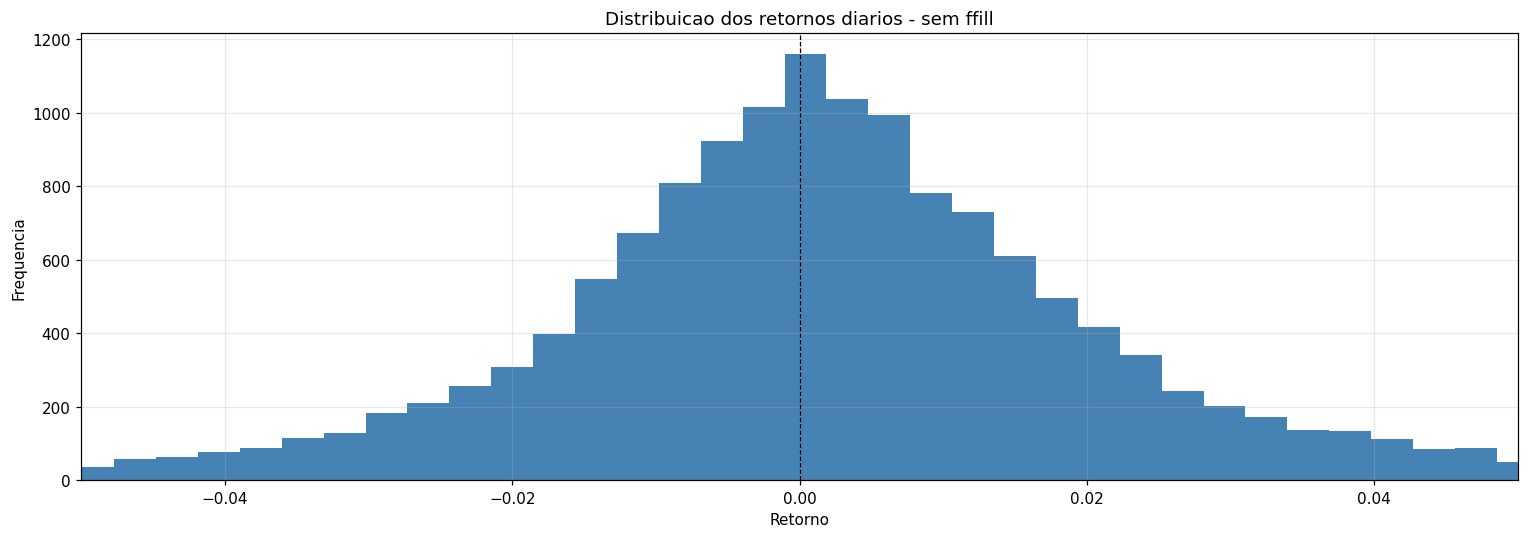

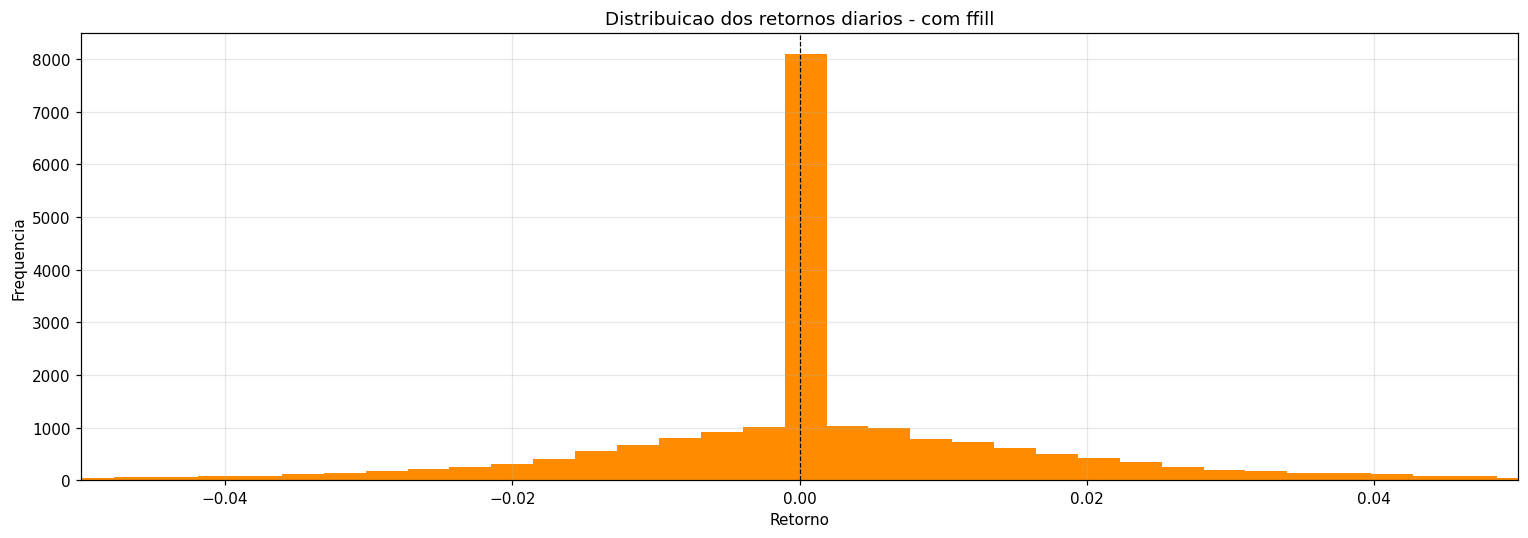

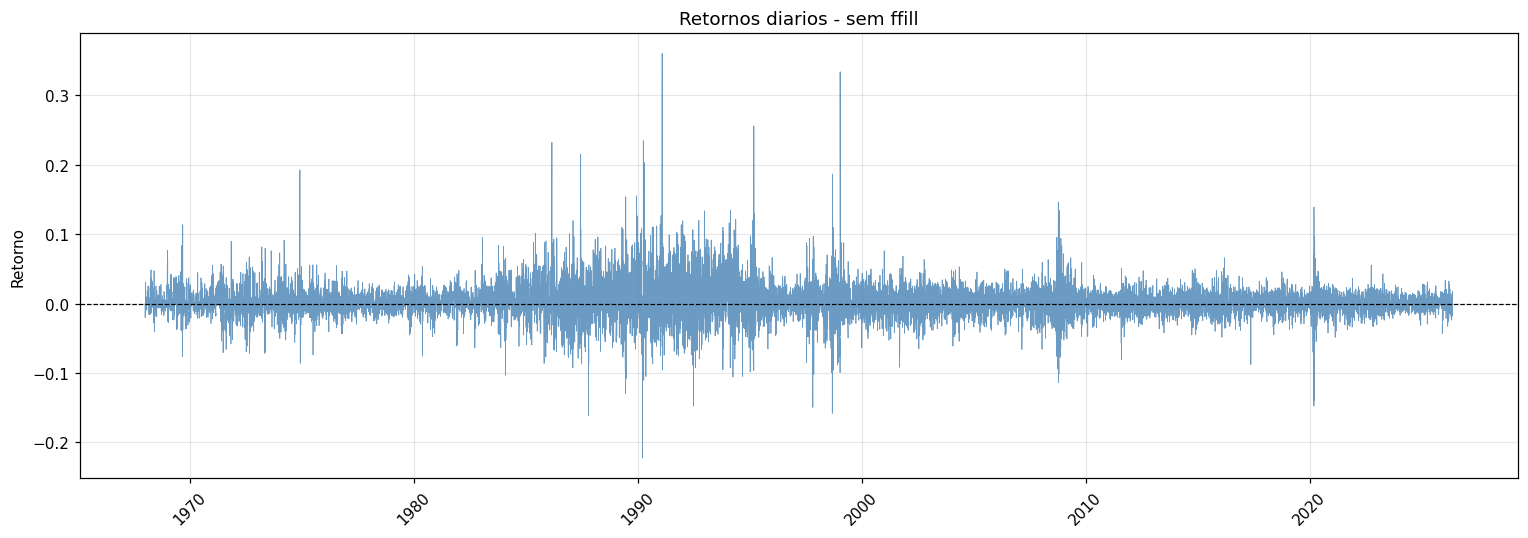

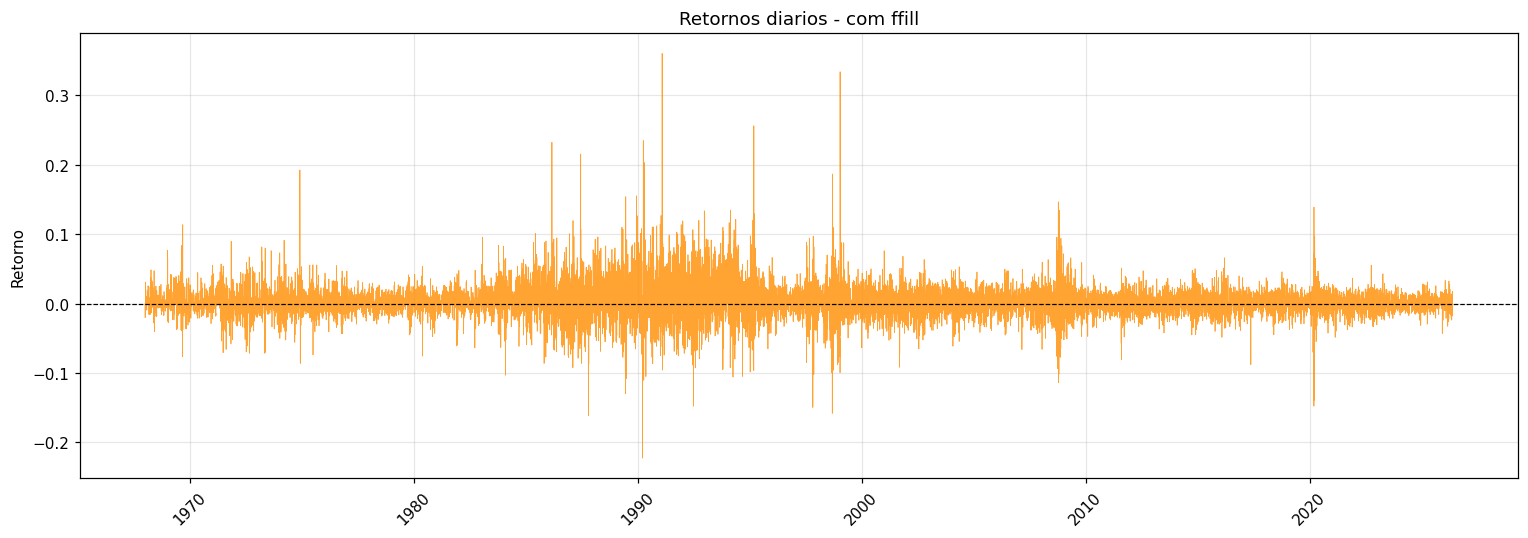

Retorno medio diario (sem ffill): 0.2741%
Desvio padrao diario (sem ffill): 2.4662%
Retorno medio diario (com ffill): 0.1851%
Desvio padrao diario (com ffill): 2.0304%

Retorno medio diario >= 2010 (sem ffill): 0.0332%
Desvio padrao diario >= 2010 (sem ffill): 1.4512%
Retorno medio diario >= 2010 (com ffill): 0.0226%
Desvio padrao diario >= 2010 (com ffill): 1.1958%


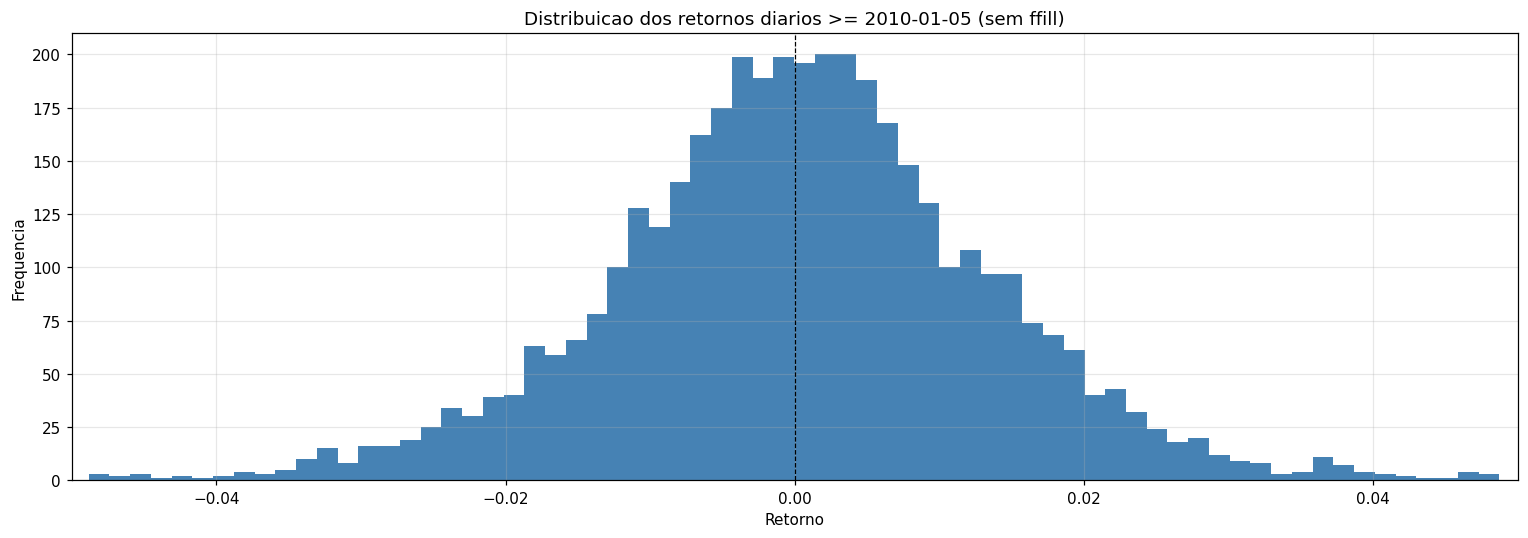

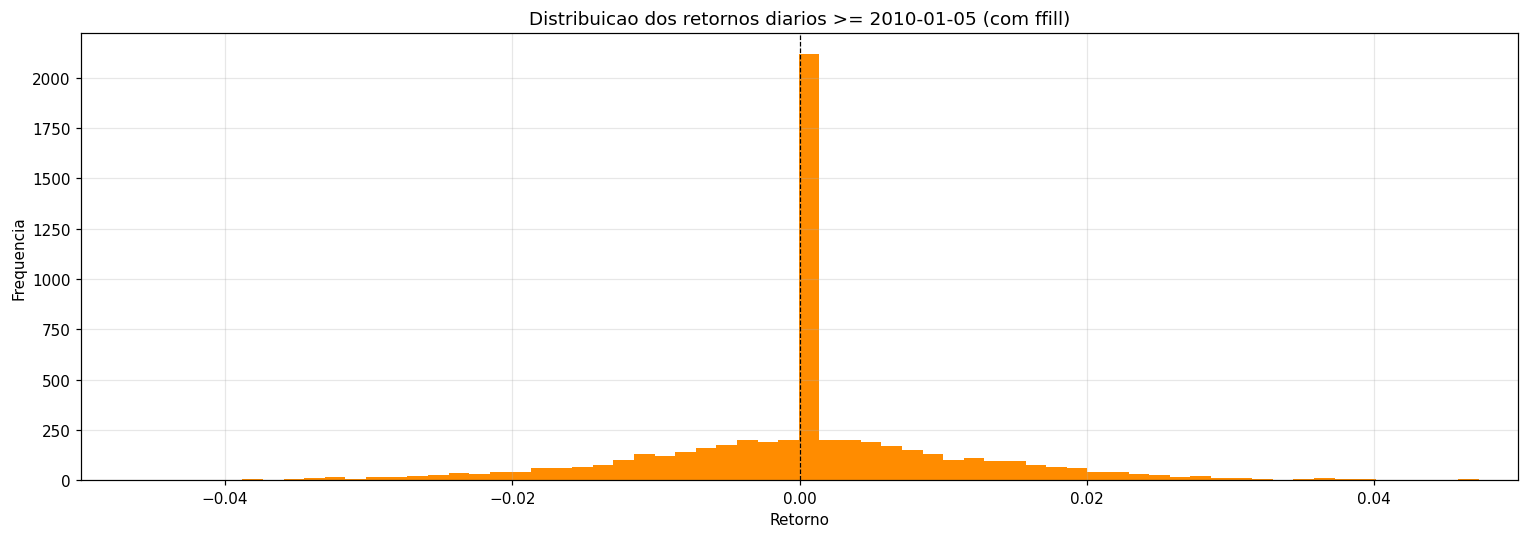

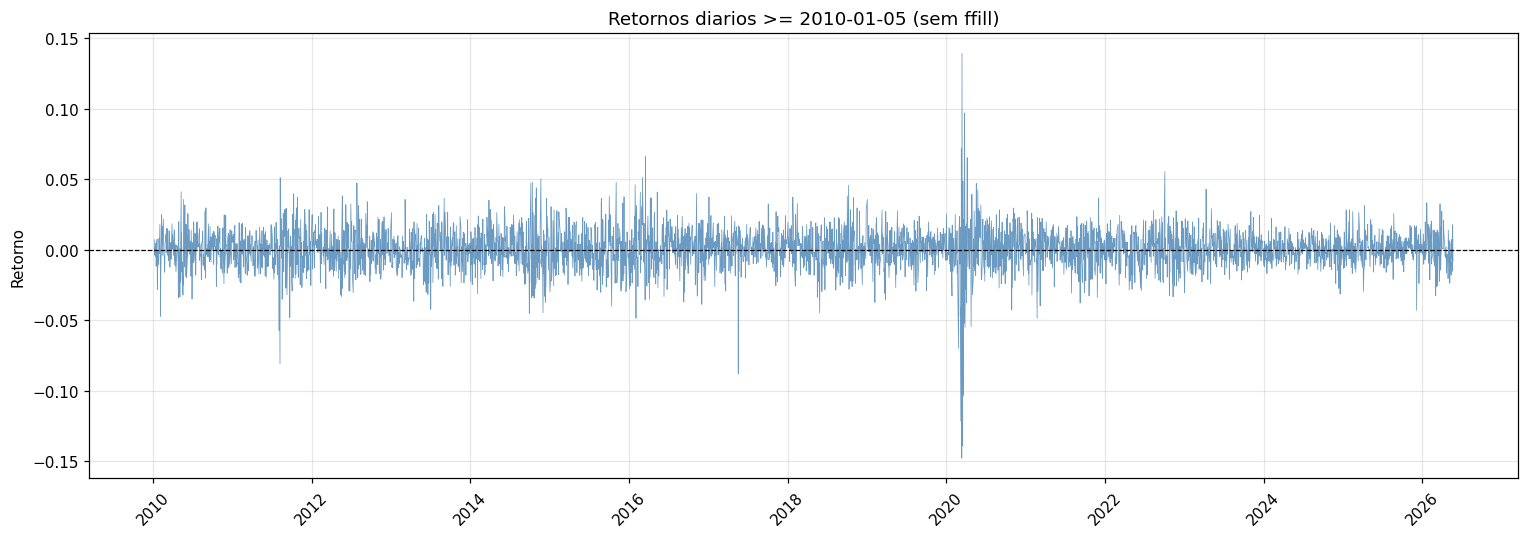

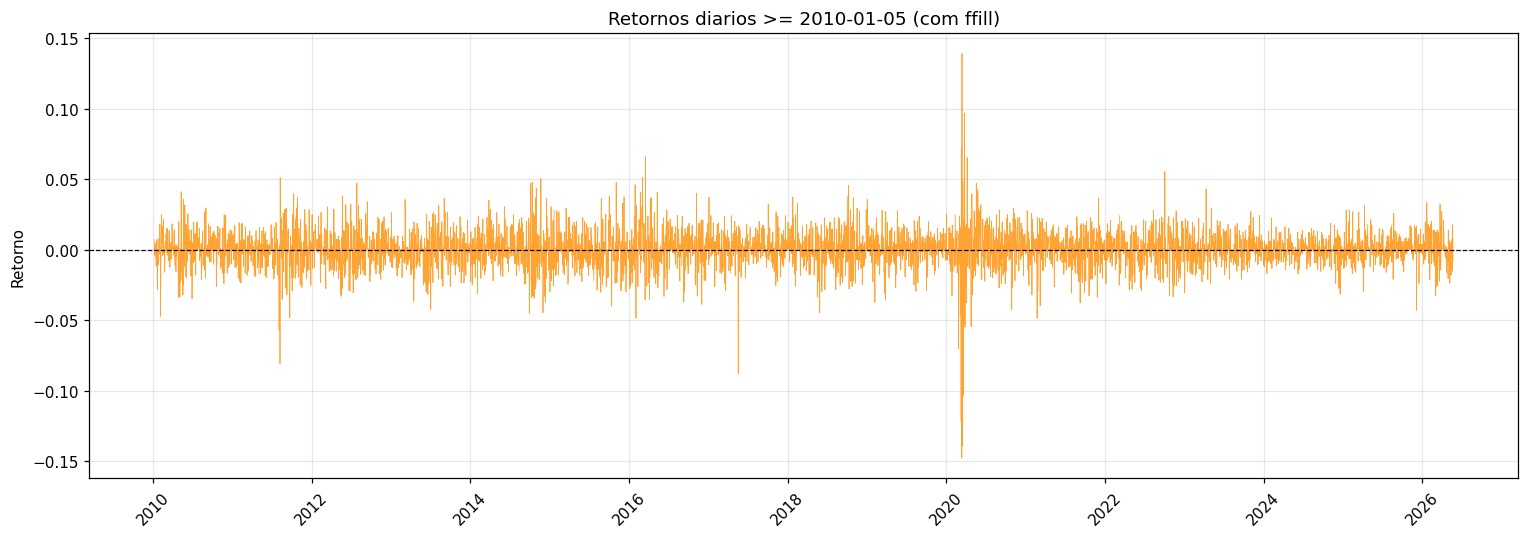

In [160]:
ibov['retorno'] = ibov['valor'].pct_change()
ibov_ff['retorno'] = ibov_ff['valor'].pct_change()

# --- distribuicao sem ffill (completo) ---
plt.close('all')
plt.figure(figsize=(14, 5))
plt.hist(ibov['retorno'].dropna(), bins=200, color='steelblue', edgecolor='none')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Distribuicao dos retornos diarios - sem ffill')
plt.xlabel('Retorno')
plt.ylabel('Frequencia')
plt.xlim(-0.05, 0.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- distribuicao com ffill (completo) ---
plt.figure(figsize=(14, 5))
plt.hist(ibov_ff['retorno'].dropna(), bins=200, color='darkorange', edgecolor='none')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Distribuicao dos retornos diarios - com ffill')
plt.xlabel('Retorno')
plt.ylabel('Frequencia')
plt.xlim(-0.05, 0.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- serie temporal sem ffill (completo) ---
plt.figure(figsize=(14, 5))
plt.plot(ibov['data'], ibov['retorno'], linewidth=0.5, color='steelblue', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Retornos diarios - sem ffill')
plt.ylabel('Retorno')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- serie temporal com ffill (completo) ---
plt.figure(figsize=(14, 5))
plt.plot(ibov_ff['data'], ibov_ff['retorno'], linewidth=0.5, color='darkorange', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Retornos diarios - com ffill')
plt.ylabel('Retorno')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Retorno medio diario (sem ffill):', f"{ibov['retorno'].mean():.4%}")
print('Desvio padrao diario (sem ffill):', f"{ibov['retorno'].std():.4%}")
print('Retorno medio diario (com ffill):', f"{ibov_ff['retorno'].mean():.4%}")
print('Desvio padrao diario (com ffill):', f"{ibov_ff['retorno'].std():.4%}")

ibov_2010    = ibov[ibov['data'] >= '2010-01-05'].copy()
ibov_ff_2010 = ibov_ff[ibov_ff['data'] >= '2010-01-05'].copy()
ibov_2010['retorno']    = ibov_2010['valor'].pct_change()
ibov_ff_2010['retorno'] = ibov_ff_2010['valor'].pct_change()

print('\nRetorno medio diario >= 2010 (sem ffill):', f"{ibov_2010['retorno'].mean():.4%}")
print('Desvio padrao diario >= 2010 (sem ffill):', f"{ibov_2010['retorno'].std():.4%}")
print('Retorno medio diario >= 2010 (com ffill):', f"{ibov_ff_2010['retorno'].mean():.4%}")
print('Desvio padrao diario >= 2010 (com ffill):', f"{ibov_ff_2010['retorno'].std():.4%}")

# --- distribuicao sem ffill (>= 2010) ---
plt.figure(figsize=(14, 5))
plt.hist(ibov_2010['retorno'].dropna(), bins=200, color='steelblue', edgecolor='none')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Distribuicao dos retornos diarios >= 2010-01-05 (sem ffill)')
plt.xlabel('Retorno')
plt.ylabel('Frequencia')
plt.xlim(-0.05, 0.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- distribuicao com ffill (>= 2010) ---
plt.figure(figsize=(14, 5))
plt.hist(ibov_ff_2010['retorno'].dropna(), bins=200, color='darkorange', edgecolor='none')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Distribuicao dos retornos diarios >= 2010-01-05 (com ffill)')
plt.xlabel('Retorno')
plt.ylabel('Frequencia')
plt.xlim(-0.05, 0.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- serie temporal sem ffill (>= 2010) ---
plt.figure(figsize=(14, 5))
plt.plot(ibov_2010['data'], ibov_2010['retorno'], linewidth=0.5, color='steelblue', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Retornos diarios >= 2010-01-05 (sem ffill)')
plt.ylabel('Retorno')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- serie temporal com ffill (>= 2010) ---
plt.figure(figsize=(14, 5))
plt.plot(ibov_ff_2010['data'], ibov_ff_2010['retorno'], linewidth=0.5, color='darkorange', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Retornos diarios >= 2010-01-05 (com ffill)')
plt.ylabel('Retorno')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Medias moveis

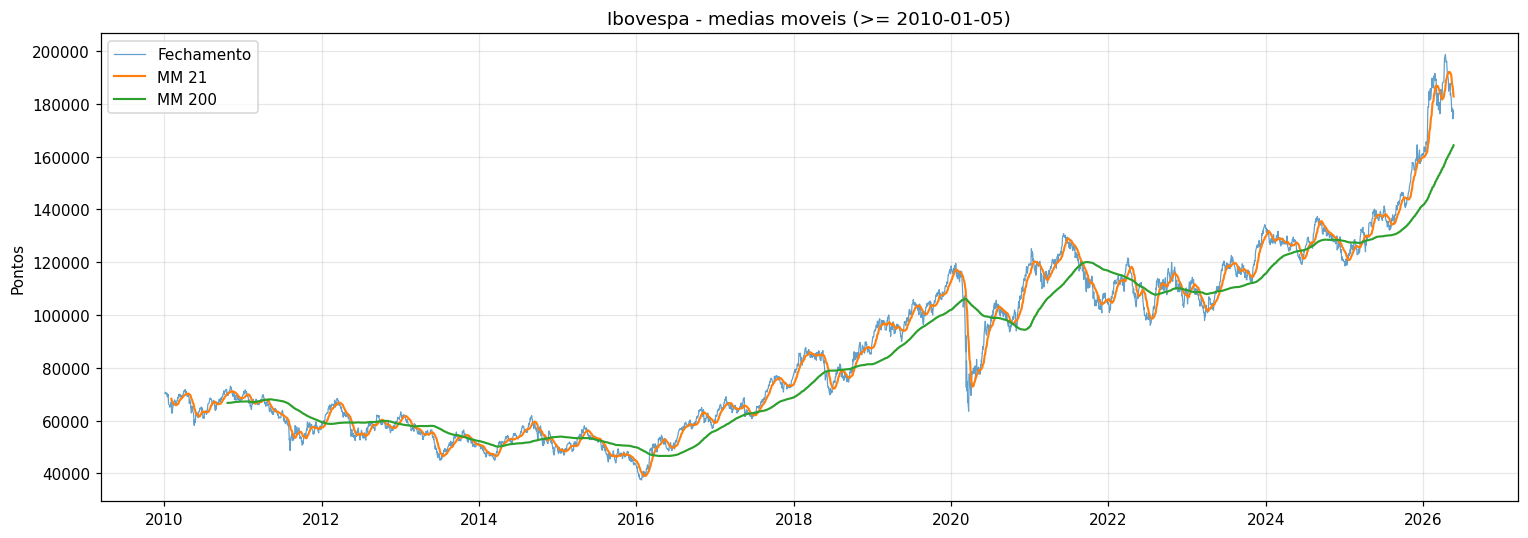

In [161]:
recente = ibov[ibov['data'] >= '2010-01-05'].copy()
recente['mm21']  = recente['valor'].rolling(21).mean()
recente['mm200'] = recente['valor'].rolling(200).mean()
plt.figure(figsize=(14, 5))
plt.plot(recente['data'], recente['valor'],  label='Fechamento', linewidth=0.8, alpha=0.7)
plt.plot(recente['data'], recente['mm21'],   label='MM 21',  linewidth=1.4)
plt.plot(recente['data'], recente['mm200'],  label='MM 200', linewidth=1.4)
plt.title('Ibovespa - medias moveis (>= 2010-01-05)')
plt.ylabel('Pontos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Volatilidade realizada (janela 21 dias uteis)

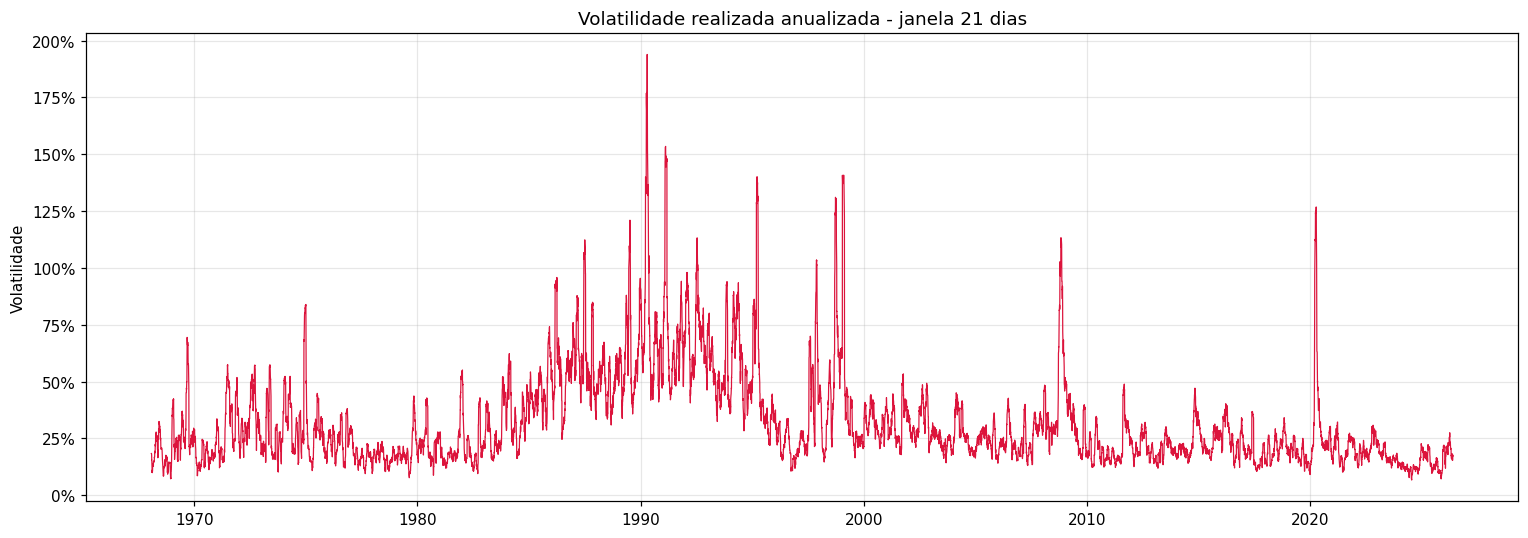

In [162]:
ibov['vol21'] = ibov['retorno'].rolling(21).std() * np.sqrt(252)

plt.plot(ibov['data'], ibov['vol21'], color='crimson', linewidth=0.8)
plt.title('Volatilidade realizada anualizada - janela 21 dias')
plt.ylabel('Volatilidade')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Salvando novo arquivo

In [ ]:
arq = open('dados/Historico_retornos.csv', 'w')
arq.write('data,valor,retorno\n')

for _, row in ibov.iterrows():
    arq.write(f"{row['data'].date()},{row['valor']},{row['retorno']}\n")
    
arq.close()

arq_ff = open('dados/Historico_retornos_ffill.csv', 'w')
arq_ff.write('data,valor,retorno\n')

for _, row in ibov_ff.iterrows():
    arq_ff.write(f"{row['data'].date()},{row['valor']},{row['retorno']}\n")

arq_ff.close()